<a href="https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/Entornos_Complejos/DiferenciaTemporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metodos Aproximados**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "MountainCar"**:
Se carga la versión del entorno "MountainCar".

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### **Código de la Instalación e Importación**
----

%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


# Instalación de algunos paquetes.
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay

!pip install gymnasium gymnasium[box2d]

In [1]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG
from src.agents.AgenteDT_Double_Deep_QL import AgenteDT_DobleDeepQL
from src.agents.AgenteDT_Deep_QL import AgenteDT_DeepQL

from src.tilings.tiling import TileCodingEnv

from src.ploting import *

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cuda


In [3]:
#@title Importamos el lago helado
video_folder = "./videos"  # Asegúrate de que esta ruta coincide con la carpeta donde se guardan los videos
name = 'MountainCar-v0'
render = "rgb_array"
env = gym.make(name, render_mode=render, max_episode_steps=500 )

In [4]:
#@title Generamos 4 mosaicos (tilings) con 20x20 intervalos. Al nuevo espacio lo llamaremos *tcenv*
tilings = 4
bins = np.array([20, 20])
low = env.observation_space.low
high = env.observation_space.high
tcenv = TileCodingEnv(env, bins=bins, low=low, high=high, seed=seed, n=tilings)
print("Se muestran los 4 mosáicos")
tcenv.tilings

Se muestran los 4 mosáicos


[[array([-1.0649961 , -0.9664089 , -0.8678217 , -0.7692344 , -0.67064726,
         -0.57206   , -0.47347277, -0.37488556, -0.27629834, -0.17771113,
         -0.07912391,  0.0194633 ,  0.11805058,  0.21663773,  0.315225  ,
          0.41381216,  0.51239944,  0.6109867 ,  0.70957386], dtype=float32),
  array([-0.05803319, -0.05005461, -0.04207603, -0.03409745, -0.02611887,
         -0.01814029, -0.01016171, -0.00218313,  0.00579545,  0.01377403,
          0.02175261,  0.02973119,  0.03770977,  0.04568835,  0.05366693,
          0.06164551,  0.06962409,  0.07760266,  0.08558124], dtype=float32)],
 [array([-1.0812603 , -0.97939503, -0.87752974, -0.7756644 , -0.6737991 ,
         -0.5719338 , -0.47006845, -0.36820316, -0.26633787, -0.16447258,
         -0.06260729,  0.039258  ,  0.14112341,  0.2429887 ,  0.344854  ,
          0.4467193 ,  0.5485846 ,  0.6504499 ,  0.7523152 ], dtype=float32),
  array([-0.06204324, -0.05381159, -0.04557995, -0.0373483 , -0.02911665,
         -0.020885  , -0.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes: las políticas de toma de decisiones y el algoritmo de aprendizaje. En este cuaderno nos centraremos en algoritmos de **Métodos Aproximados** para espacios de estados continuos.

### **Métodos Aproximados en Aprendizaje por Refuerzo**
Los Métodos Aproximados son técnicas que permiten escalar los algoritmos de aprendizaje por refuerzo a problemas con espacios de estados y acciones grandes o continuos. En lugar de mantener una tabla Q completa, estos métodos utilizan funciones aproximadoras (como características escaladas o redes neuronales) para estimar la función de valor:

$$\hat{V}(s) \approx V(s) \quad \text{o} \quad \hat{Q}(s,a) \approx Q(s,a)$$

En nuestro caso, utilizaremos dos enfoques:
*   **Tile Coding** con Semi-Gradiente: Discretización del espacio continuo mediante mosaicos para SARSA Semi-Gradiente.
*   **Redes Neuronales Profundas**: Aproximación no-lineal del espacio de valores para Deep Q-Learning y Double Deep Q-Learning.

### **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad no nula de ser elegidas. Todos los pares estado-acción tienen una probabilidad de selección mínima de $\epsilon/|A|$.
   - **Política epsilon-greedy**: Basada en la política epsilon-soft. El agente tiene una pequeña probabilidad $\epsilon$ de explorar (tomar una acción aleatoria) y una mayor probabilidad $1-\epsilon$ de explotar (tomar la acción que considera mejor según su aproximación actual). Esto permite equilibrar la exploración y la explotación de manera efectiva.
   - **Política greedy**: Selecciona siempre la acción con el mayor valor estimado. Es la usada una vez que el agente "ha aprendido" para evaluar su comportamiento final.

### **Algoritmos Implementados**

#### **1. SARSA Semi-Gradiente (State-Action-Reward-State-Action)**
SARSA Semi-Gradiente es un algoritmo **On-Policy** que combina ideas de Diferencia Temporal con métodos aproximados. Aprende la función de valor de acción $\hat{Q}(s, a)$ para la política de comportamiento actual utilizando características escaladas derivadas del Tile Coding.

La regla de actualización es:
$$w \leftarrow w + \alpha [R_{t+1} + \gamma \hat{Q}(S_{t+1}, A_{t+1}) - \hat{Q}(S_t, A_t)] \nabla \hat{Q}(S_t, A_t)$$

donde $w$ representa los pesos de las características y $\nabla \hat{Q}$ es el gradiente de la función de valor aproximada respecto a sus pesos.

#### **2. Deep Q-Learning (DQL)**
Deep Q-Learning utiliza una red neuronal profunda para aproximar la función de valor de acción óptima $\hat{Q}(s, a; \theta)$. Es un algoritmo **Off-Policy** que permite aprender una política greedy mientras se explora con una política epsilon-greedy.

La regla de actualización utiliza pérdida Mean Squared Error:
$$L(\theta) = \mathbb{E}[(R_{t+1} + \gamma \max_{a'} \hat{Q}(S_{t+1}, a'; \theta^-) - \hat{Q}(S_t, A_t; \theta))^2]$$

donde $\theta^-$ son los pesos de una **red objetivo** (target network) que se actualiza periódicamente para estabilizar el entrenamiento.

Además, cuenta con una memoria donde se van almacendo las últimos 1000 acciones.

#### **3. Double Deep Q-Learning (DDQL)**
Double Deep Q-Learning resuelve el **sesgo de maximización** presente en Deep Q-Learning. Utiliza dos redes neuronales independientes: una para seleccionar la mejor acción y otra para estimar su valor.

La regla de actualización es:
$$L(\theta) = \mathbb{E}[(R_{t+1} + \gamma \hat{Q}(S_{t+1}, \mathop{\mathrm{argmax}}_{a'} \hat{Q}(S_{t+1}, a'; \theta); \theta^-) - \hat{Q}(S_t, A_t; \theta))^2]$$

Además, cuenta con una memoria donde se van almacendo las últimos 1000 acciones.

Esta estrategia desacopla la selección de acciones de su evaluación, reduciendo significativamente la sobreestimación.



#### **Funciones de Entrenamiento**

A continuación se describen las funciones que orquestan el aprendizaje de los agentes.

##### **Algoritmo de Diferencia Temporal**
El algoritmo de entrenamiento de diferencias temporales es el mismo empleado en el notebook de ``DiferenciaTemporal``.

##### **Algoritmo de Deep Q-Learning (`entrenamientoDeepQL`)**
Esta función implementa el bucle de entrenamiento específico para **Deep Q-Networks (DQN)** y sus variantes (como Double DQN). Analizando el código, se destacan tres componentes clave que lo diferencian del TD clásico:

1.  **Recolección y Almacenamiento de Experiencia:**
    *   En lugar de actualizar el valor Q inmediatamente y desechar la transición, se utiliza `agente.save_experience(state, action, reward, new_state, done)`.
    *   Esto permite llenar el **Experience Replay Buffer**, fundamental para romper la correlación secuencial de los datos y estabilizar el entrenamiento de la red neuronal.

2.  **Paso de Aprendizaje (`agente.update()`):**
    *   Se llama en cada paso de tiempo. Internamente, el agente no aprende solo de la última experiencia, sino que toma un **minilote (minibatch)** aleatorio de la memoria para calcular la pérdida y actualizar los pesos de la red mediante descenso de gradiente.

3.  **Sincronización de la Red Objetivo (Target Network):**
    *   Se utiliza un contador global (`global_step`).
    *   La sincronización se realiza cada 500 pasos, asegurandose que los pesos de la red objetivo ($\theta^-$) se congelen y solo se actualicen periódicamente con los de la red principal ($\theta$). Esto evita que el objetivo de aprendizaje cambie constantemente (problema del *moving target*).

In [5]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def diferencia_temporal(tcenv, agente, num_episodes=5000):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = tcenv.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        # Selección inicial de la acción (necesario para métodos On-Policy como SARSA)
        action = agente.get_action(state, t)
        while not done:
            # Ejecución de la acción en el entorno
            new_state, reward, done, truncated, _ = tcenv.step(action)
            done = done or truncated
            
            # Selección de la siguiente acción (A' en la tupla SARSA)
            new_action = agente.get_action(new_state, t)
            
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            
            # Actualización del agente (Paso de aprendizaje TD)
            agente.update(state, action, reward, new_state, new_action, done)
            
            result_sum += reward
            state = new_state
            action = new_action

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}, Alpha: {agente.alpha:.3f}")

    return list_stats, all_episode_lengths

from tqdm import tqdm

#@title Algoritmo de Iteración de Deep Q-Learning con Redes Neuronales
def entrenamientoDeepQL(tcenv, agente, num_episodes=5000, target_update_freq=100):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    
    global_step = 0 # Contador global de pasos para sincronizar la red objetivo
    
    for t in tqdm(range(num_episodes)):
        state, info = tcenv.reset(seed=seed) 
        done = False
        episode = []
        result_sum  = 0.0
        c = 0
        
        while not done:
            # Seleccionar acción con política epsilon-greedy
            action = agente.get_action(state, t)
            
            # Ejecutar acción en el entorno
            new_state, reward, terminated, truncated, _ = tcenv.step(action)
            done = truncated or terminated
            
            # Guardamos la experiencia en el Replay Buffer (Memoria)
            episode.append((state, action, reward))
            agente.save_experience(state, action, reward, new_state, done)
            
            # --- EL CAMBIO CRÍTICO: ENTRENAR DENTRO DEL BUCLE ---
            # El agente aprende tomando un minilote aleatorio de la memoria
            agente.update()
            
            # --- ACTUALIZACIÓN DE RED OBJETIVO POR PASOS ---
            # Cada 'target_update_freq' pasos, copiamos los pesos de la red Q a la red objetivo
            if global_step % target_update_freq == 0 and global_step > 0:
                agente.update_target_network()
            
            result_sum += reward
            state = new_state
            c += 1
            global_step += 1
            
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")

    return list_stats, all_episode_lengths

## **3. Experimentación**

En esta sección realizaremos una comparativa exhaustiva de los algoritmos de Métodos Aproximados (SARSA Semi-Gradiente, Deep Q-Learning y Double Deep Q-Learning) en el entorno continuo de MountainCar, utilizando Tile Coding para la discretización del espacio de estados.

### **Metodología Experimental**
Para cada algoritmo (SARSA Semi-Gradiente, Deep Q-Learning y Double Deep Q-Learning), seguiremos el siguiente procedimiento:

1.  **Preparación del Entorno y Discretización**:
    -   El entorno utilizado es **MountainCar-v0**, un problema de control continuo donde el agente debe aprender a conducir un coche en una montaña sin suficiente potencia para subir directamente.
    -   Dado que el espacio de estados es continuo, aplicamos **Tile Coding** para discretizarlo: utilizamos $n=4$ tilings (mosaicos) con bins de $20 \times 20$ intervalos, lo que permite representar eficientemente el espacio continuo mediante una codificación distribuida.

2.  **Entrenamiento**:
    -   Se ejecutará cada algoritmo durante un número fijo de **5,000 episodios**.
    -   Utilizaremos una política **epsilon-greedy** con decaimiento exponencial. Para SARSA Semi-Gradiente iniciaremos con $\epsilon=0.2$ y para Deep QL con $\epsilon=0.3$, valores que disminuirán progresivamente conforme avanza el entrenamiento, favoreciendo la explotación.
    -   El factor de descuento $\gamma$ se fija en 0.99 para dar importancia a las recompensas futuras en este entorno de aprendizaje lento.
    -   Para los algoritmos basados en redes neuronales (Deep QL y Double Deep QL), se actualiza la red objetivo cada 500 pasos para estabilizar el entrenamiento evitando correlaciones en los datos de entrenamiento.

3.  **Visualización y Análisis de Resultados**:
    -   **Proporción de Recompensas**: Gráfica de la media acumulada de recompensas obtenidas ($f(t)=\frac{\sum_{i=1}^t R_i}{t}$). Refleja la estabilidad y velocidad de convergencia del aprendizaje, indicando cuántas veces el agente logra alcanzar la meta.
    -   **Longitud del Episodio**: Gráfica del número de pasos requeridos por episodio. Una disminución indica que el agente aprende estrategias más eficientes para alcanzar la meta.
    -   **Comparativa de Algoritmos**: Análisis lado a lado del comportamiento de los tres métodos aproximados (SARSA SG, Deep QL, Double Deep QL) para identificar cuál converge más rápidamente y logra mejor desempeño.
    -   **Video de demostración**: Generación de GIFs de episodios demostrativos usando la política greedy derivada del aprendizaje para verificar cualitativamente el comportamiento final del agente.

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.


### **3.2 Experimentación en el escenario**

A continuación se van a realizar el entrenamiento de los algoritmos de SARSA semi-gradiante, Deep Q-learning y Double Deep Q-learning. Para cada agente, se van a realizar 5000 episodios.




#### **3.2.1 Algoritmo de SARSA Semi-Gradiante**

En primer lugar, se entrena el algoritmo Sarsa Semi-gradiente.

In [6]:
# @title Aprendizaje
agente_DT_Sarsa_V4 = AgenteDT_SarsaSG(tcenv, seed, discount_factor=0.99, epsilon=0.25, decay=True, num_episodes=5000, decay_rate=200.0)
stats_sarsa, lengths_sarsa = diferencia_temporal(tcenv, agente=agente_DT_Sarsa_V4, num_episodes=5000)

 10%|█         | 521/5000 [00:08<00:40, 109.93it/s]

Episode: 500, Avg Return: -361.98, Epsilon: 0.200, Alpha: 0.422


 20%|██        | 1021/5000 [00:12<00:33, 120.55it/s]

Episode: 1000, Avg Return: -279.17, Epsilon: 0.200, Alpha: 0.279


 30%|███       | 1511/5000 [00:16<00:32, 108.43it/s]

...

 80%|████████  | 4025/5000 [00:34<00:06, 150.47it/s]

Episode: 4000, Avg Return: -189.71, Epsilon: 0.050, Alpha: 0.236


 91%|█████████ | 4530/5000 [00:37<00:03, 137.29it/s]

Episode: 4500, Avg Return: -185.22, Epsilon: 0.044, Alpha: 1.000


100%|██████████| 5000/5000 [00:40<00:00, 122.03it/s]


Una vez entrenado, se almacenan los resultados del entrenamiento.

In [7]:
datos_sarsa = {"sarsa": {"stats": stats_sarsa, "lengths": lengths_sarsa}}
save_training_results_to_csv("sarsa_me.csv", datos_sarsa)

Datos de entrenamiento guardados exitosamente en sarsa_me.csv


Tras almacenar los resultados en el fichero `sarsa_me.csv`, se muestra la evolución de la proporción de recompensas y la evolución de la longitud de los episodios.

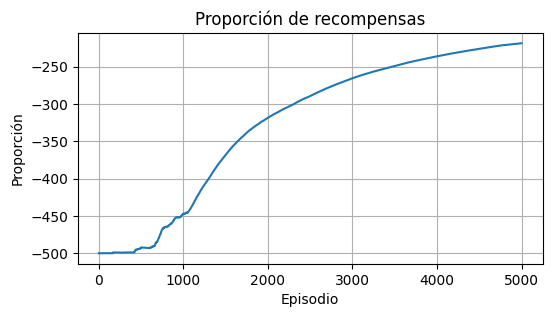

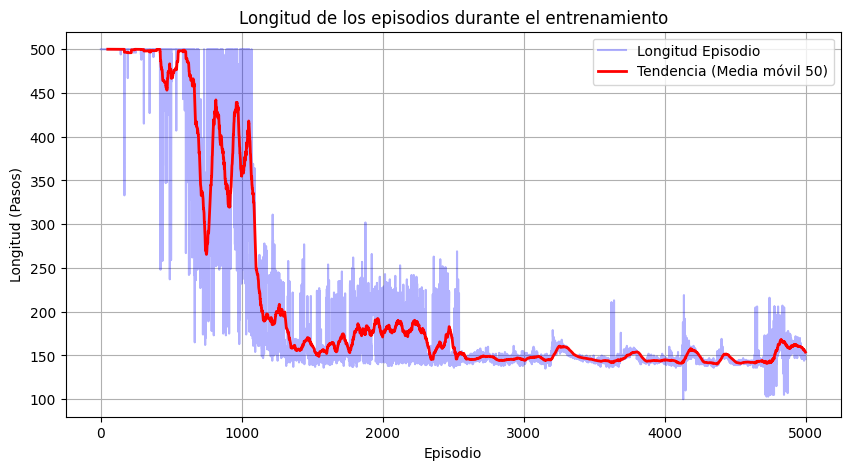

Máxima proporcion: -218.6708


In [8]:
#@title Proporción de aciertos por número de episodios
plot(stats_sarsa)
plot_lengths(lengths_sarsa)
print(f"Máxima proporcion: {stats_sarsa[-1]}")

Observamos que la gráfica comienza en -500, dado que el número máximo de pasos es 500, se podría intuir que durante el primer episodio, el coche no llega a la meta. Sin embargo, enseguida las recompensas empiezan a aumentar, mostrando una subida más pronunciada al inicio, y más lenta al final.

Respecto a la longitud de los episodios, se observa que al inicio llegan a los 500 pasos máximos que se comentó, pero antes de los 1000 pasos se muestra una caida brusca hasta unos 200 pasos por episodio. Se muestra una tendencia en la longitud de los episodios variable, que se estabiliza más conforme avanzan los episodios, llegando al final a unos 150 pasos.

Tras esto, se ejecuta un episodio con una política greedy del agente, y se almacena en `cartpole_sarsa.gif`.

In [9]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 4
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_Sarsa_V4.action_values_Q, max_steps=500)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_sarsa.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_sarsa.gif


Una vez creado, se muestra el episodio


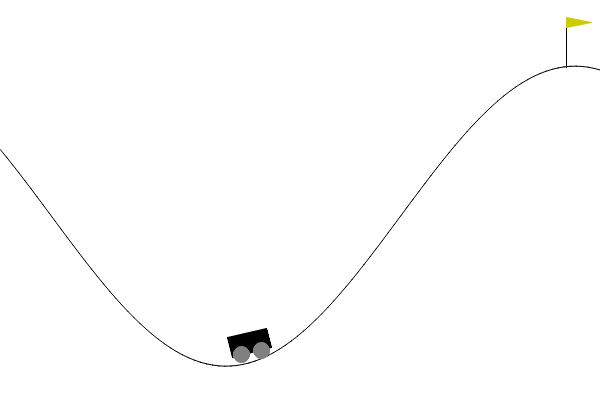

In [13]:
def display_gif2(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" style="border: 2px solid black;">')
display_gif2(gif_path)

En el episodio se puede observar que el agente tiene la estrategia de ir hacia atrás antes de subir la colina. Se observa que el agente necesita ir hacia atrás dos veces para conseguir subir la colina completa.

#### **3.2.1 Algoritmo de Deep Q-Learning**

Ahora vamos a realizar el entrenamiento utilizando el algoritmo de **Deep Q-Learning**. Para ello, se han empleado los siguientes parámetros:

- **Factor de descuento (alpha)**: 0.99
- **Epsilon Inicial**: 0.5
- **Epsilon Decay**: Activado 
- **Ratio de decay**: cada 100 episodios

In [6]:
# @title Aprendizaje
agente_DT_DQL = AgenteDT_DeepQL(tcenv, seed, discount_factor=0.99, epsilon=0.5, decay=True, num_episodes=5000, decay_rate=100.0)
stats_dql, lengths_dql = entrenamientoDeepQL(tcenv, agente=agente_DT_DQL, num_episodes=5000, target_update_freq=500)
agente_DT_DQL.save("pesos_DeepQL.pth")

 10%|█         | 501/5000 [10:52<57:06,  1.31it/s]  

Episode: 500, Avg Return: -381.21, Epsilon: 0.200


 20%|██        | 1001/5000 [18:14<50:51,  1.31it/s]  

Episode: 1000, Avg Return: -309.26, Epsilon: 0.100


 30%|███       | 1501/5000 [22:49<31:28,  1.85it/s]  

...

 80%|████████  | 4001/5000 [44:54<11:04,  1.50it/s]

Episode: 4000, Avg Return: -197.04, Epsilon: 0.025


 90%|█████████ | 4501/5000 [49:12<03:53,  2.14it/s]

Episode: 4500, Avg Return: -191.07, Epsilon: 0.022


100%|██████████| 5000/5000 [53:04<00:00,  1.57it/s]


Tras el entrenamiento se ve la evolución del return desde los primeros 500 pasos hasta los 5000 episodios, empezando desde -381 de return hasta llegar a -186. Además, se ve la evolución del epsilon, afectando a la velocidad del entrenamiento ya que cuanto mayor era, más dificil era para el modelo llegar al punto objetivo, aunque lograse explorar más.

Ahora vamos a visualizar la evolución de la recompensa y la longitud de los episodios en sus respectivas gráficas.

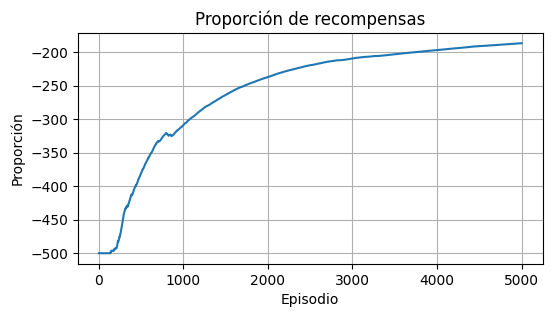

Máxima proporcion: -186.7876


In [13]:
#@title Proporción de aciertos por número de episodios

plot(stats_dql)
print(f"Máxima proporcion: {stats_dql[-1]}")


En la gráfica se puede ver esa evolución de la recompensa, donde al principio, por el elevado valor de epsilon, no logra llegar al objetivo en 500 pasos, obteniendo la mínima recompensa. Pasasdos esos primeros episodios, empieza a encontrar la solución y explotar dichas acciones que le llevan a la solución, consiguiendo que la recompensa vaya creciendo hasta llegar a un punto que parece converger. Cabe destacar esa pequeña bajada antes de llegar a los 1000 episodios que se puede deber a que en ese punto aun tenía un epsilon alto (0.1) y que aún no había conseguido aprender del todo el cámino solución.

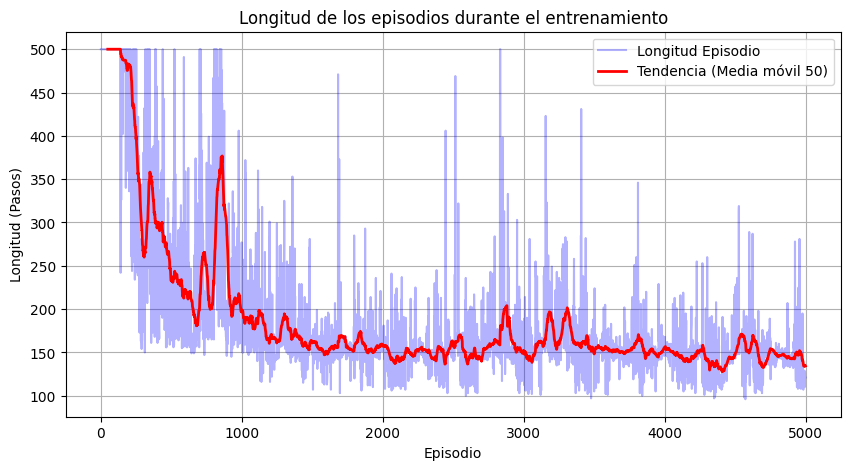

In [ ]:

plot_lengths(lengths_dql)


En esta gráfica se ve la evolución del número de pasos que realiza por episodio, sacando conclusiones similares a la anterior gráfica como esos primeros episodios donde solo se realizaban 500 pasos y esa rápida bajada en los primeros 1000 pasos. Durante el resto de episodios se ve que hay aun varios episodios en los que no se consigue una clara convergencia del número de episodios debido al uso de ese epsilon.

Ahora vamos a generar un video utilizan el agente entrenado en el mismo escenario.

In [9]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
tcenv_demo = TileCodingEnv(env, bins=bins, low=low, high=high, seed=seed, n=tilings)

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_DQL.targetNetwork, seed=seed, max_steps=500, tipo_algoritmo="QNetwork", device=agente_DT_DQL.device)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_ql.gif")
print("GIF guardado en:", gif_path)

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


GIF guardado en: cartpole_ql.gif



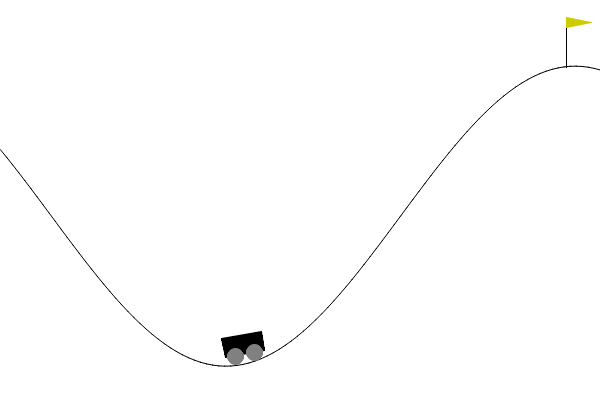

In [ ]:
display_gif(gif_path)

En el video se puede ver que el agente consigue aprender correctamente la estratégia correcta para llegar al objetivo haciendo el mínimo número de balanceos.

#### **3.2.1 Algoritmo de Doble Deep Q-Learning**
Ahora vamos a realizar el entrenamiento utilizando el algoritmo de **Double Deep Q-Learning**. Para ello, se han empleado los siguientes parámetros:

- **Factor de descuento (alpha)**: 0.99
- **Epsilon Inicial**: 0.5
- **Epsilon Decay**: Activado 
- **Ratio de decay**: cada 200 episodios

En este caso se ha aumentado el ratio de decay para obligar al agente a explorar más, ya que con valores más bajos no lograba aprender la estrategia óptima.

In [6]:
# @title Aprendizaje
agente_DT_DDQL = AgenteDT_DobleDeepQL(tcenv, seed, discount_factor=0.99, epsilon=0.5, decay=True, num_episodes=5000, decay_rate=200.0)
stats_ddql, lengths_ddql = entrenamientoDeepQL(tcenv, agente=agente_DT_DDQL, num_episodes=5000, target_update_freq=500)
agente_DT_DDQL.save("pesos_DoubleDeepQL.pth")

 10%|█         | 501/5000 [11:26<1:36:16,  1.28s/it]

Episode: 500, Avg Return: -407.37, Epsilon: 0.399


 20%|██        | 1001/5000 [19:02<47:24,  1.41it/s] 

Episode: 1000, Avg Return: -340.58, Epsilon: 0.200


 30%|███       | 1501/5000 [24:31<37:19,  1.56it/s]  

...

 80%|████████  | 4001/5000 [51:07<07:02,  2.36it/s]

Episode: 4000, Avg Return: -216.34, Epsilon: 0.050


 90%|█████████ | 4501/5000 [56:23<04:52,  1.70it/s]

Episode: 4500, Avg Return: -209.26, Epsilon: 0.044


100%|██████████| 5000/5000 [1:01:18<00:00,  1.36it/s]


Tras el entrenamiento se ve la evolución del return desde los primeros 500 pasos hasta los 5000 episodios, empezando desde -407de return hasta llegar a -205, valores por encima que el agente anterior debido a ese aumento del ratio de decay. Sin embargo, esto conseguirá que el agente explore más otras estrategias, sobre todo al inicio.

Ahora vamos a visualizar la evolución de la recompensa y la longitud de los episodios en sus respectivas gráficas.

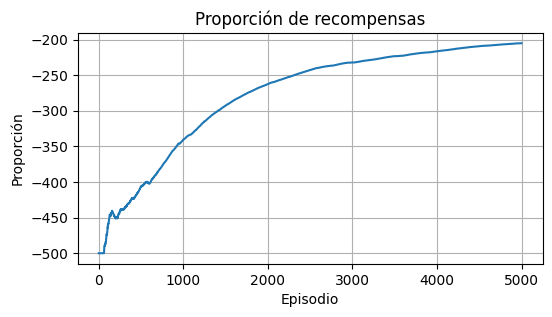

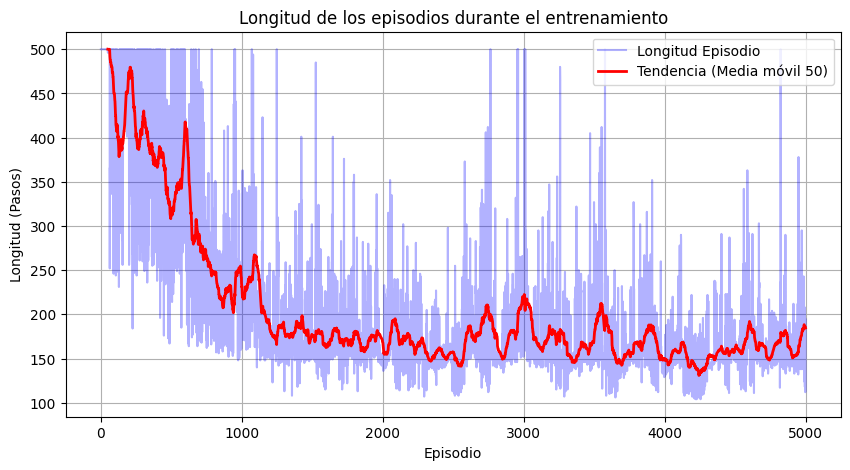

Máxima proporcion: -205.0126


In [7]:
#@title Proporción de aciertos por número de episodios

plot(stats_ddql)
print(f"Máxima proporcion: {stats_ddql[-1]}")


En la gráfica se puede ver esa evolución de la recompensa, donde al inicio ocurre algo similar a antes donde no encontraba la solución y obtenía la mínima recompensa. Sin embargo, debido a ese mayor ratio, se aprecia como la evolución de este agente es más lento que el anterior.

In [ ]:
plot_lengths(lengths_ddql)


En cuanto a la gráfica de las longitudes de los episodios, nos volvemos a encontrar una situación similar a la del agente anterior, donde hay un inicio donde solo se realizan episodios de 500 pasos y luego empieza a decaer hasta estabilizar la media entren los 200 y 150 pasos. Por otro lado, volvemos a encontrarnos con muchos episodios con valores altos de pasos debido a esa posible exploración en sus acciones por el valor de epsilon.

Finalmente, vamos a generar el video donde vemos al agente solucionar el problema.

In [9]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
tcenv_demo = TileCodingEnv(env, bins=bins, low=low, high=high, seed=seed, n=tilings)

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_DDQL.qNetwork, seed=seed, max_steps=1000, tipo_algoritmo="QNetwork", device=agente_DT_DDQL.device)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_ddql.gif")
print("GIF guardado en:", gif_path)

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


GIF guardado en: cartpole_ddql.gif



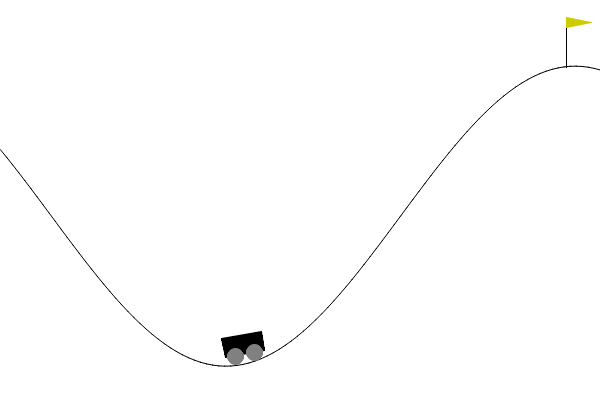

In [10]:
display_gif(gif_path)

También vemos que el agente logra llegar al objetivo siguendo la estratégia que menos balanceos necesita.

Ahora vamos a guardar los resultados de los entrenamientos para poder analizarlos en conjunto

In [12]:
# Guardar resultados de todos los entrenamientos en un CSV para comparativa posterior
# Asegúrate de haber ejecutado todos los entrenamientos anteriores
try:
    results_all = {
        'SARSA_SG': {'stats': stats_sarsa, 'lengths': lengths_sarsa},
        'Deep_Q-Learning': {'stats': stats_dql, 'lengths': lengths_dql},
        'Double Deep Q-Learning': {'stats': stats_ddql, 'lengths': lengths_ddql}
    }
    
    # Intentamos usar la función de src.ploting.
    # Si no se encuentra (porque el módulo no se ha recargado), la definimos in-line o avisamos
    if 'save_training_results_to_csv' in globals():
        save_training_results_to_csv("resultados_metodos_aproximados.csv", results_all)
    else:
        # Intento de recarga dinámica por si acaso
        import importlib
        import src.ploting
        importlib.reload(src.ploting)
        from src.ploting import save_training_results_to_csv
        save_training_results_to_csv("resultados_metodos_aproximados.csv", results_all)

except NameError as e:
    print(f"No se pudieron guardar los resultados completos. Faltan variables: {e}")
    print("Asegúrate de ejecutar las celdas de entrenamiento de SARSA, Deep QL y Double Deep QL.")

Datos de entrenamiento guardados exitosamente en resultados_metodos_aproximados.csv


## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**


### **4.2 Propuestas para Estudios Futuros**

